In [263]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    confusion_matrix,
)

In [264]:
df = pd.read_csv("data/other/laptops-v1.csv")

In [265]:
df.shape

(791, 16)

In [266]:
df.head()

,Brand,Model,Type,Dimension (in),Screen Resolution,CPU Brand,CPU Model,CPU Frequency (GHz),GPU Brand,GPU Model,RAM (GB),HDD,SSD,OS,Weight (kg),Price (Euro)
0,HP,250 G6,Notebook,15.6,1920x1080,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,8,False,True,No OS,1.86,575.00
1,Asus,ZenBook UX430UN,Ultrabook,NaN,1920x1080,Intel,Core i7 8550U,1.8,Nvidia,GeForce MX150,16,False,True,Windows,1.30,1495.00
2,Acer,Swift 3,Ultrabook,14.0,1920x1080,Intel,Core i5 8250U,1.6,Intel,UHD Graphics 620,8,False,True,Windows,1.60,770.00
3,HP,250 G6,Notebook,15.6,1366x768,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,4,True,False,No OS,1.86,393.90
4,HP,250 G6,Notebook,15.6,1920x1080,Intel,Core i3 6006U,2.0,Intel,HD Graphics 520,4,True,False,No OS,1.86,344.99


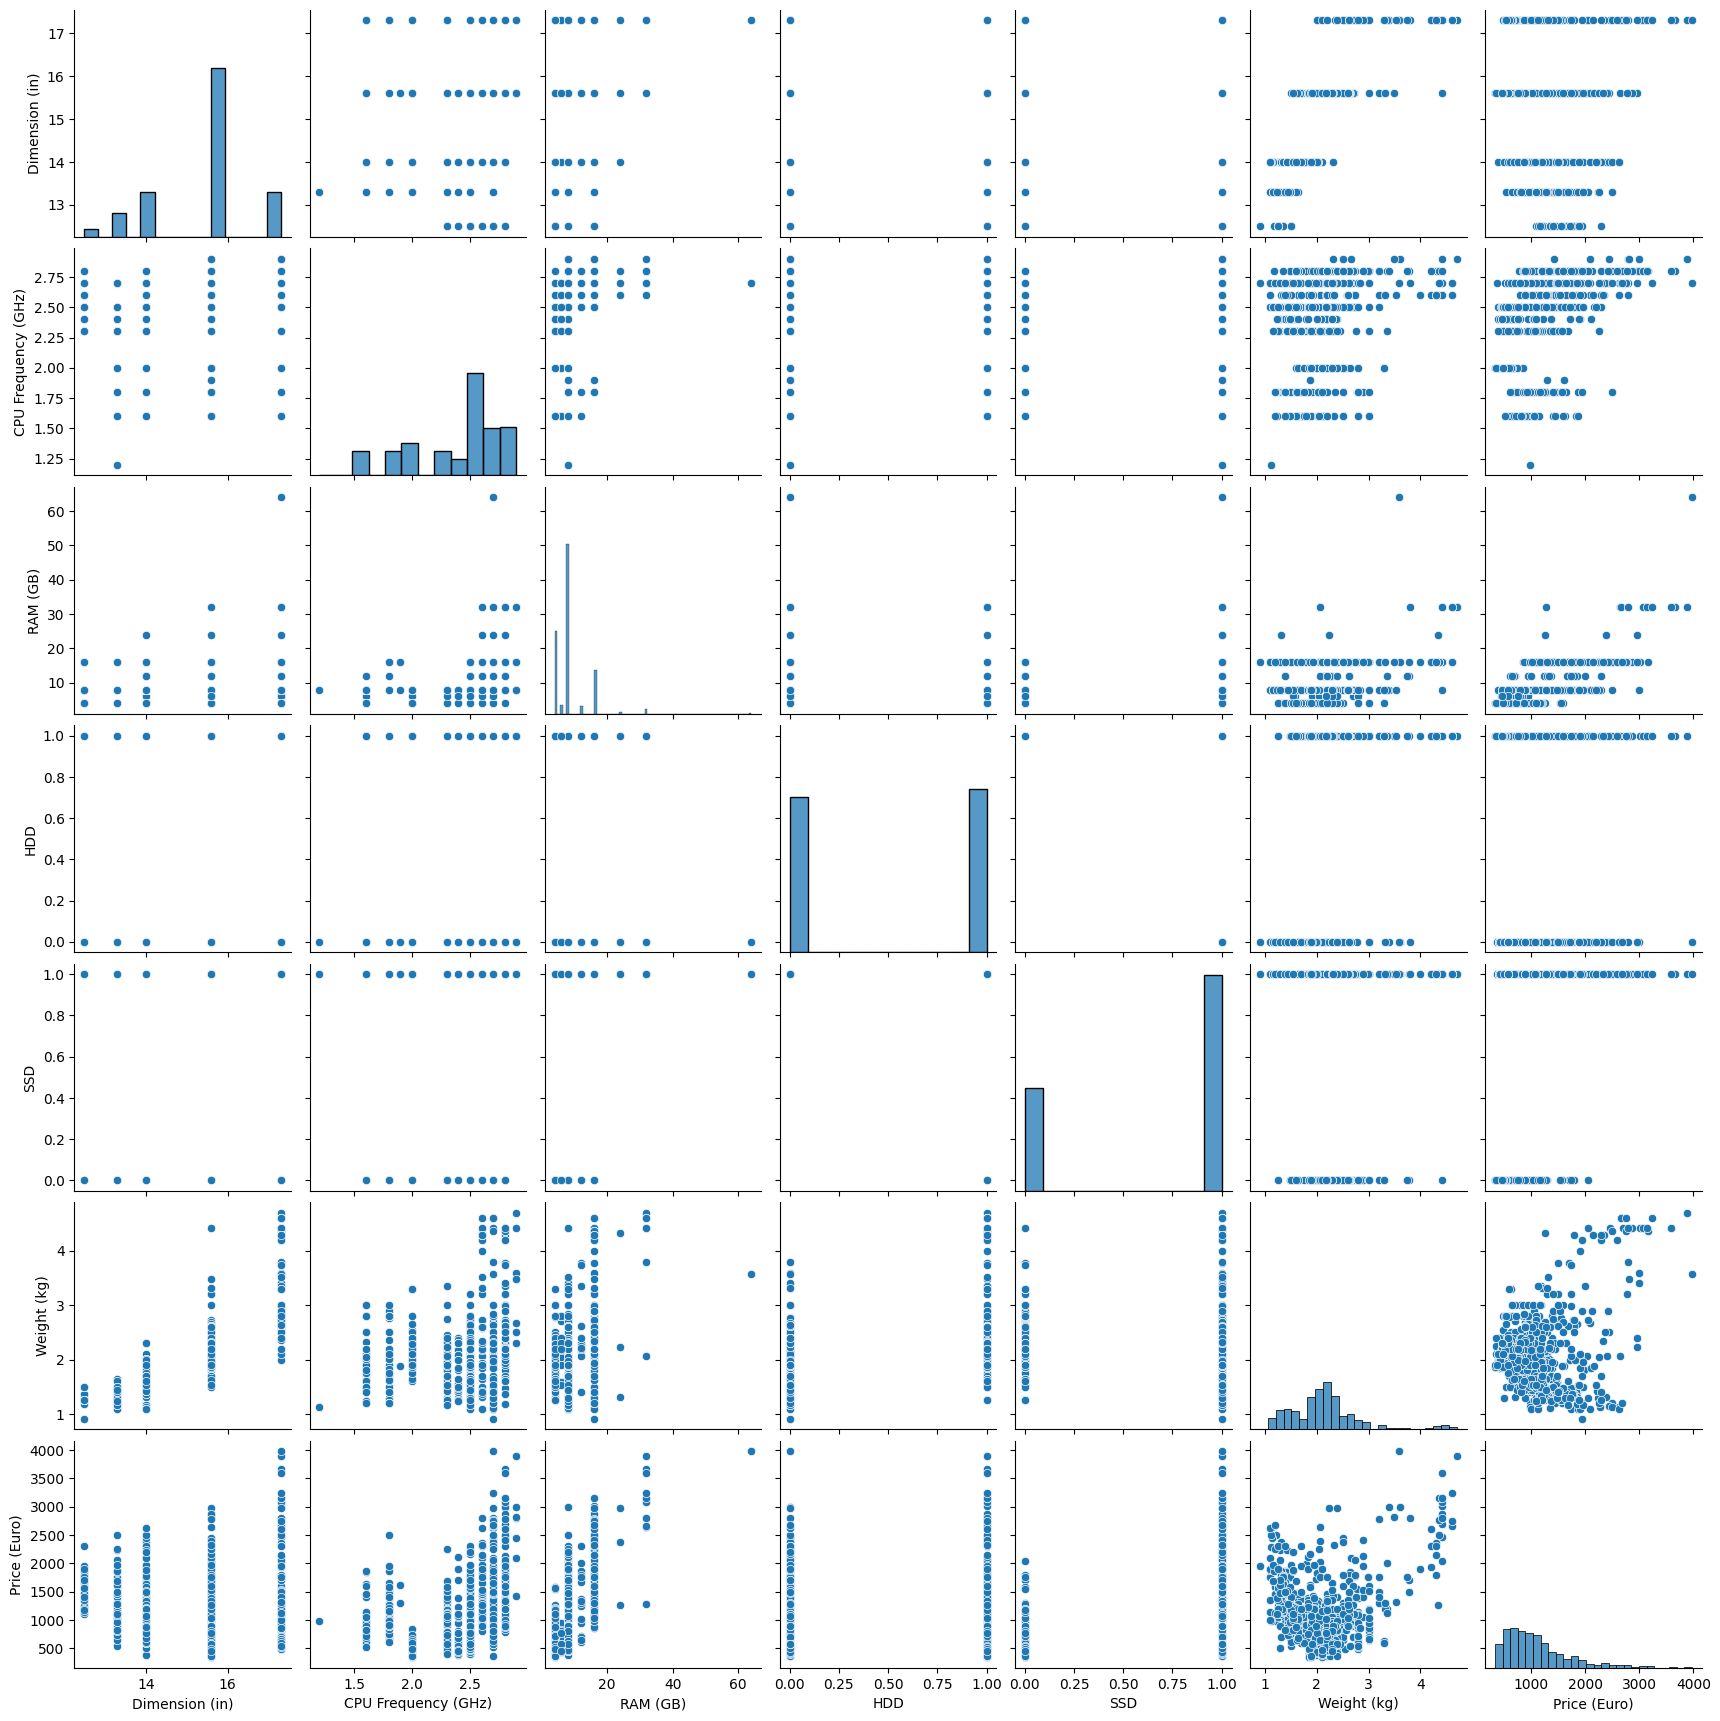

In [267]:
sns.pairplot(df)

<Axes: >

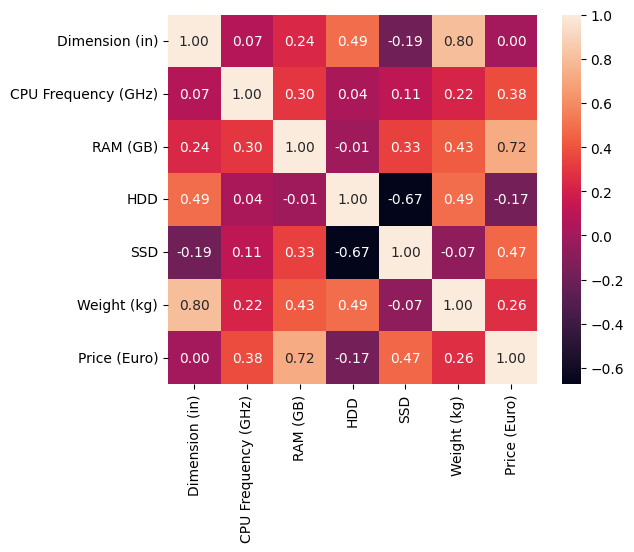

In [268]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", square=True)

<Axes: >

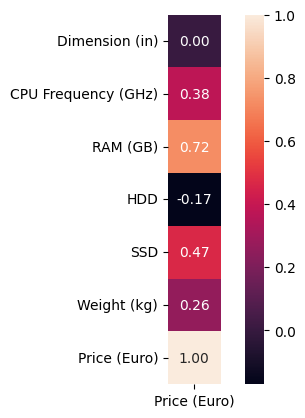

In [269]:
sns.heatmap(df.corr(numeric_only=True)[["Price (Euro)"]], annot=True, fmt=".2f", square=True)

In [270]:
df["Type"].unique()

array(['Notebook', 'Ultrabook', 'Gaming'], dtype=object)

<Axes: xlabel='Type', ylabel='Price (Euro)'>

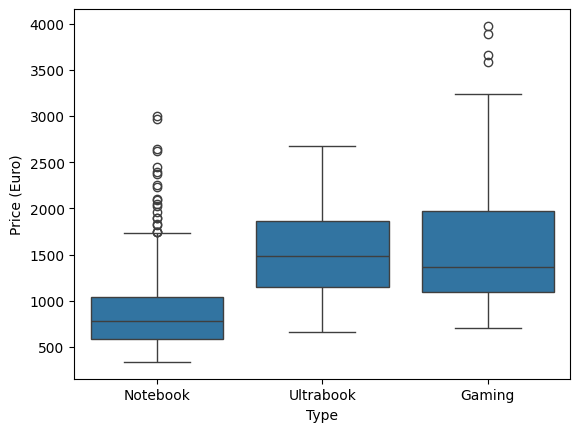

In [271]:
sns.boxplot(df, x="Type", y="Price (Euro)")

In [272]:
counts_by_type = df["Type"].value_counts()

<Axes: xlabel='Type', ylabel='count'>

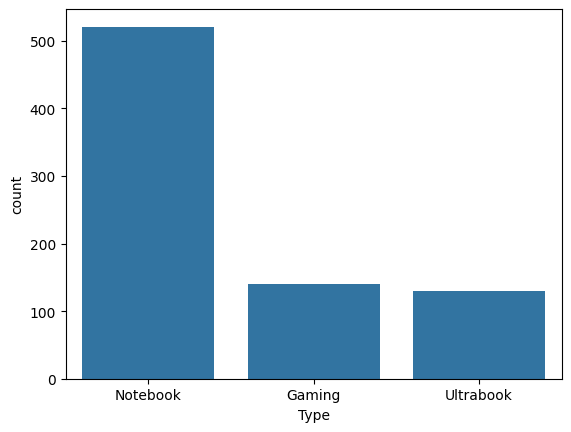

In [273]:
sns.barplot(counts_by_type)

In [274]:
df.head()

,Brand,Model,Type,Dimension (in),Screen Resolution,CPU Brand,CPU Model,CPU Frequency (GHz),GPU Brand,GPU Model,RAM (GB),HDD,SSD,OS,Weight (kg),Price (Euro)
0,HP,250 G6,Notebook,15.6,1920x1080,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,8,False,True,No OS,1.86,575.00
1,Asus,ZenBook UX430UN,Ultrabook,NaN,1920x1080,Intel,Core i7 8550U,1.8,Nvidia,GeForce MX150,16,False,True,Windows,1.30,1495.00
2,Acer,Swift 3,Ultrabook,14.0,1920x1080,Intel,Core i5 8250U,1.6,Intel,UHD Graphics 620,8,False,True,Windows,1.60,770.00
3,HP,250 G6,Notebook,15.6,1366x768,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,4,True,False,No OS,1.86,393.90
4,HP,250 G6,Notebook,15.6,1920x1080,Intel,Core i3 6006U,2.0,Intel,HD Graphics 520,4,True,False,No OS,1.86,344.99


In [275]:
df.isnull().sum()

Brand                   0
Model                   0
Type                    0
Dimension (in)         74
Screen Resolution       0
CPU Brand               0
CPU Model               0
CPU Frequency (GHz)     0
GPU Brand               0
GPU Model              49
RAM (GB)                0
HDD                     0
SSD                     0
OS                      0
Weight (kg)            49
Price (Euro)           10
dtype: int64

In [276]:
df["Brand"].unique()

array(['HP', 'Asus', 'Acer', 'Dell', 'Lenovo'], dtype=object)

In [277]:
df = pd.concat([df, pd.get_dummies(df["Brand"])], axis=1)
df.drop(columns=["Brand"], inplace=True)

In [278]:
df.head()

,Model,Type,Dimension (in),Screen Resolution,CPU Brand,CPU Model,CPU Frequency (GHz),GPU Brand,GPU Model,RAM (GB),HDD,SSD,OS,Weight (kg),Price (Euro),Acer,Asus,Dell,HP,Lenovo
0,250 G6,Notebook,15.6,1920x1080,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,8,False,True,No OS,1.86,575.00,False,False,False,True,False
1,ZenBook UX430UN,Ultrabook,NaN,1920x1080,Intel,Core i7 8550U,1.8,Nvidia,GeForce MX150,16,False,True,Windows,1.30,1495.00,False,True,False,False,False
2,Swift 3,Ultrabook,14.0,1920x1080,Intel,Core i5 8250U,1.6,Intel,UHD Graphics 620,8,False,True,Windows,1.60,770.00,True,False,False,False,False
3,250 G6,Notebook,15.6,1366x768,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,4,True,False,No OS,1.86,393.90,False,False,False,True,False
4,250 G6,Notebook,15.6,1920x1080,Intel,Core i3 6006U,2.0,Intel,HD Graphics 520,4,True,False,No OS,1.86,344.99,False,False,False,True,False


In [279]:
df["Model"].unique().shape

(340,)

In [280]:
df.drop(columns=["Model"], inplace=True)

In [281]:
df.head()

,Type,Dimension (in),Screen Resolution,CPU Brand,CPU Model,CPU Frequency (GHz),GPU Brand,GPU Model,RAM (GB),HDD,SSD,OS,Weight (kg),Price (Euro),Acer,Asus,Dell,HP,Lenovo
0,Notebook,15.6,1920x1080,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,8,False,True,No OS,1.86,575.00,False,False,False,True,False
1,Ultrabook,NaN,1920x1080,Intel,Core i7 8550U,1.8,Nvidia,GeForce MX150,16,False,True,Windows,1.30,1495.00,False,True,False,False,False
2,Ultrabook,14.0,1920x1080,Intel,Core i5 8250U,1.6,Intel,UHD Graphics 620,8,False,True,Windows,1.60,770.00,True,False,False,False,False
3,Notebook,15.6,1366x768,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,4,True,False,No OS,1.86,393.90,False,False,False,True,False
4,Notebook,15.6,1920x1080,Intel,Core i3 6006U,2.0,Intel,HD Graphics 520,4,True,False,No OS,1.86,344.99,False,False,False,True,False


In [282]:
df["Type"].unique()

array(['Notebook', 'Ultrabook', 'Gaming'], dtype=object)

In [283]:
df = pd.concat([df, pd.get_dummies(df["Type"])], axis=1)
df.drop(columns=["Type"], inplace=True)

In [284]:
df.head()

,Dimension (in),Screen Resolution,CPU Brand,CPU Model,CPU Frequency (GHz),GPU Brand,GPU Model,RAM (GB),HDD,SSD,...,Weight (kg),Price (Euro),Acer,Asus,Dell,HP,Lenovo,Gaming,Notebook,Ultrabook
0,15.6,1920x1080,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,8,False,True,...,1.86,575.00,False,False,False,True,False,False,True,False
1,NaN,1920x1080,Intel,Core i7 8550U,1.8,Nvidia,GeForce MX150,16,False,True,...,1.30,1495.00,False,True,False,False,False,False,False,True
2,14.0,1920x1080,Intel,Core i5 8250U,1.6,Intel,UHD Graphics 620,8,False,True,...,1.60,770.00,True,False,False,False,False,False,False,True
3,15.6,1366x768,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,4,True,False,...,1.86,393.90,False,False,False,True,False,False,True,False
4,15.6,1920x1080,Intel,Core i3 6006U,2.0,Intel,HD Graphics 520,4,True,False,...,1.86,344.99,False,False,False,True,False,False,True,False


In [285]:
df[["Width", "Height"]] = df["Screen Resolution"].str.split("x").tolist()
df["Width"] = df["Width"].astype(int)
df["Height"] = df["Height"].astype(int)
df.drop(columns=["Screen Resolution"], inplace=True)

In [286]:
df.head()

,Dimension (in),CPU Brand,CPU Model,CPU Frequency (GHz),GPU Brand,GPU Model,RAM (GB),HDD,SSD,OS,...,Acer,Asus,Dell,HP,Lenovo,Gaming,Notebook,Ultrabook,Width,Height
0,15.6,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,8,False,True,No OS,...,False,False,False,True,False,False,True,False,1920,1080
1,NaN,Intel,Core i7 8550U,1.8,Nvidia,GeForce MX150,16,False,True,Windows,...,False,True,False,False,False,False,False,True,1920,1080
2,14.0,Intel,Core i5 8250U,1.6,Intel,UHD Graphics 620,8,False,True,Windows,...,True,False,False,False,False,False,False,True,1920,1080
3,15.6,Intel,Core i5 7200U,2.5,Intel,HD Graphics 620,4,True,False,No OS,...,False,False,False,True,False,False,True,False,1366,768
4,15.6,Intel,Core i3 6006U,2.0,Intel,HD Graphics 520,4,True,False,No OS,...,False,False,False,True,False,False,True,False,1920,1080


In [287]:
df["CPU Brand"].unique()

array(['Intel'], dtype=object)

In [288]:
df.drop(columns=["CPU Brand"], inplace=True)

In [289]:
df["CPU Model"].unique()

array(['Core i5 7200U', 'Core i7 8550U', 'Core i5 8250U', 'Core i3 6006U',
       'Core i7 7500U', 'Core i3 7100U', 'Core i5 7300HQ',
       'Core i7 8650U', 'Core i3 7130U', 'Core i7 7700HQ',
       'Core i7 7560U', 'Core i5 7500U', 'Core i5 7Y54', 'Core i5 6200U',
       'Core i7 7820HK', 'Core i5 7300U', 'Core i7 7600U',
       'Core i7 6500U', 'Core i7 7820HQ', 'Core i5 7440HQ',
       'Core i7 6600U', 'Core i7 6700HQ', 'Core i3 6100U',
       'Core i7 6820HK', 'Core i5 6300U', 'Core i5 6300HQ',
       'Core i7 6820HQ', 'Core i7 7660U'], dtype=object)

In [290]:
df["CPU Series"] = df["CPU Model"].str[6:7].astype(int)
df.drop(columns=["CPU Model"], inplace=True)

In [291]:
df.head()

,Dimension (in),CPU Frequency (GHz),GPU Brand,GPU Model,RAM (GB),HDD,SSD,OS,Weight (kg),Price (Euro),...,Asus,Dell,HP,Lenovo,Gaming,Notebook,Ultrabook,Width,Height,CPU Series
0,15.6,2.5,Intel,HD Graphics 620,8,False,True,No OS,1.86,575.00,...,False,False,True,False,False,True,False,1920,1080,5
1,NaN,1.8,Nvidia,GeForce MX150,16,False,True,Windows,1.30,1495.00,...,True,False,False,False,False,False,True,1920,1080,7
2,14.0,1.6,Intel,UHD Graphics 620,8,False,True,Windows,1.60,770.00,...,False,False,False,False,False,False,True,1920,1080,5
3,15.6,2.5,Intel,HD Graphics 620,4,True,False,No OS,1.86,393.90,...,False,False,True,False,False,True,False,1366,768,5
4,15.6,2.0,Intel,HD Graphics 520,4,True,False,No OS,1.86,344.99,...,False,False,True,False,False,True,False,1920,1080,3


In [292]:
df["GPU Brand"].unique()

array(['Intel', 'Nvidia', 'AMD'], dtype=object)

In [293]:
df = pd.concat([df, pd.get_dummies(df["GPU Brand"])], axis=1)
df.drop(columns=["GPU Brand"], inplace=True)

In [294]:
df.head()

,Dimension (in),CPU Frequency (GHz),GPU Model,RAM (GB),HDD,SSD,OS,Weight (kg),Price (Euro),Acer,...,Lenovo,Gaming,Notebook,Ultrabook,Width,Height,CPU Series,AMD,Intel,Nvidia
0,15.6,2.5,HD Graphics 620,8,False,True,No OS,1.86,575.00,False,...,False,False,True,False,1920,1080,5,False,True,False
1,NaN,1.8,GeForce MX150,16,False,True,Windows,1.30,1495.00,False,...,False,False,False,True,1920,1080,7,False,False,True
2,14.0,1.6,UHD Graphics 620,8,False,True,Windows,1.60,770.00,True,...,False,False,False,True,1920,1080,5,False,True,False
3,15.6,2.5,HD Graphics 620,4,True,False,No OS,1.86,393.90,False,...,False,False,True,False,1366,768,5,False,True,False
4,15.6,2.0,HD Graphics 520,4,True,False,No OS,1.86,344.99,False,...,False,False,True,False,1920,1080,3,False,True,False


In [295]:
df["GPU Model"].unique()

array(['HD Graphics 620', 'GeForce MX150', 'UHD Graphics 620',
       'HD Graphics 520', 'Radeon R5 M430', 'GeForce 940MX',
       'GeForce GTX 1050', 'Radeon 530', 'GeForce 930MX',
       'GeForce GTX 1060', nan, 'Radeon 520', 'GeForce GTX 1050 Ti',
       'GeForce MX130', 'GeForce GTX 940MX', 'Iris Plus Graphics 640',
       'GeForce 920MX', 'Radeon R7 M445', 'GeForce GTX 1050M',
       'R17M-M1-70', 'GeForce 150MX', 'HD Graphics 615',
       'GeForce GTX 950M', 'GeForce GTX 1080', 'GeForce GTX 980M',
       'GeForce GTX 1070', 'Radeon RX 550', 'HD Graphics',
       'GeForce GT 940MX', 'HD Graphics 630', 'Quadro M2200M',
       'Radeon R7 M460', 'FirePro W4190M', 'HD Graphics 530',
       'GeForce GTX 965M', 'GeForce GTX1080', 'GeForce GTX1050 Ti',
       'GeForce GTX 960M', 'Radeon R5 M420', 'Quadro M620M',
       'GeForce GTX 960<U+039C>', 'Graphics 620', 'GeForce GTX 960',
       'Radeon R5 520', 'Quadro M2000M', 'GeForce GTX 1070M',
       'GeForce GTX1060', 'Radeon R5 M420X', 'G

In [296]:
df.drop(columns=["GPU Model"], inplace=True)

In [297]:
df.head()

,Dimension (in),CPU Frequency (GHz),RAM (GB),HDD,SSD,OS,Weight (kg),Price (Euro),Acer,Asus,...,Lenovo,Gaming,Notebook,Ultrabook,Width,Height,CPU Series,AMD,Intel,Nvidia
0,15.6,2.5,8,False,True,No OS,1.86,575.00,False,False,...,False,False,True,False,1920,1080,5,False,True,False
1,NaN,1.8,16,False,True,Windows,1.30,1495.00,False,True,...,False,False,False,True,1920,1080,7,False,False,True
2,14.0,1.6,8,False,True,Windows,1.60,770.00,True,False,...,False,False,False,True,1920,1080,5,False,True,False
3,15.6,2.5,4,True,False,No OS,1.86,393.90,False,False,...,False,False,True,False,1366,768,5,False,True,False
4,15.6,2.0,4,True,False,No OS,1.86,344.99,False,False,...,False,False,True,False,1920,1080,3,False,True,False


In [298]:
df["OS"].unique()

array(['No OS', 'Windows', 'Linux'], dtype=object)

In [299]:
df = pd.concat([df, pd.get_dummies(df["OS"])], axis=1)
df.drop(columns=["OS"], inplace=True)

In [300]:
df.head()

,Dimension (in),CPU Frequency (GHz),RAM (GB),HDD,SSD,Weight (kg),Price (Euro),Acer,Asus,Dell,...,Ultrabook,Width,Height,CPU Series,AMD,Intel,Nvidia,Linux,No OS,Windows
0,15.6,2.5,8,False,True,1.86,575.00,False,False,False,...,False,1920,1080,5,False,True,False,False,True,False
1,NaN,1.8,16,False,True,1.30,1495.00,False,True,False,...,True,1920,1080,7,False,False,True,False,False,True
2,14.0,1.6,8,False,True,1.60,770.00,True,False,False,...,True,1920,1080,5,False,True,False,False,False,True
3,15.6,2.5,4,True,False,1.86,393.90,False,False,False,...,False,1366,768,5,False,True,False,False,True,False
4,15.6,2.0,4,True,False,1.86,344.99,False,False,False,...,False,1920,1080,3,False,True,False,False,True,False


In [301]:
df.isnull().sum()

Dimension (in)         74
CPU Frequency (GHz)     0
RAM (GB)                0
HDD                     0
SSD                     0
Weight (kg)            49
Price (Euro)           10
Acer                    0
Asus                    0
Dell                    0
HP                      0
Lenovo                  0
Gaming                  0
Notebook                0
Ultrabook               0
Width                   0
Height                  0
CPU Series              0
AMD                     0
Intel                   0
Nvidia                  0
Linux                   0
No OS                   0
Windows                 0
dtype: int64

<Axes: >

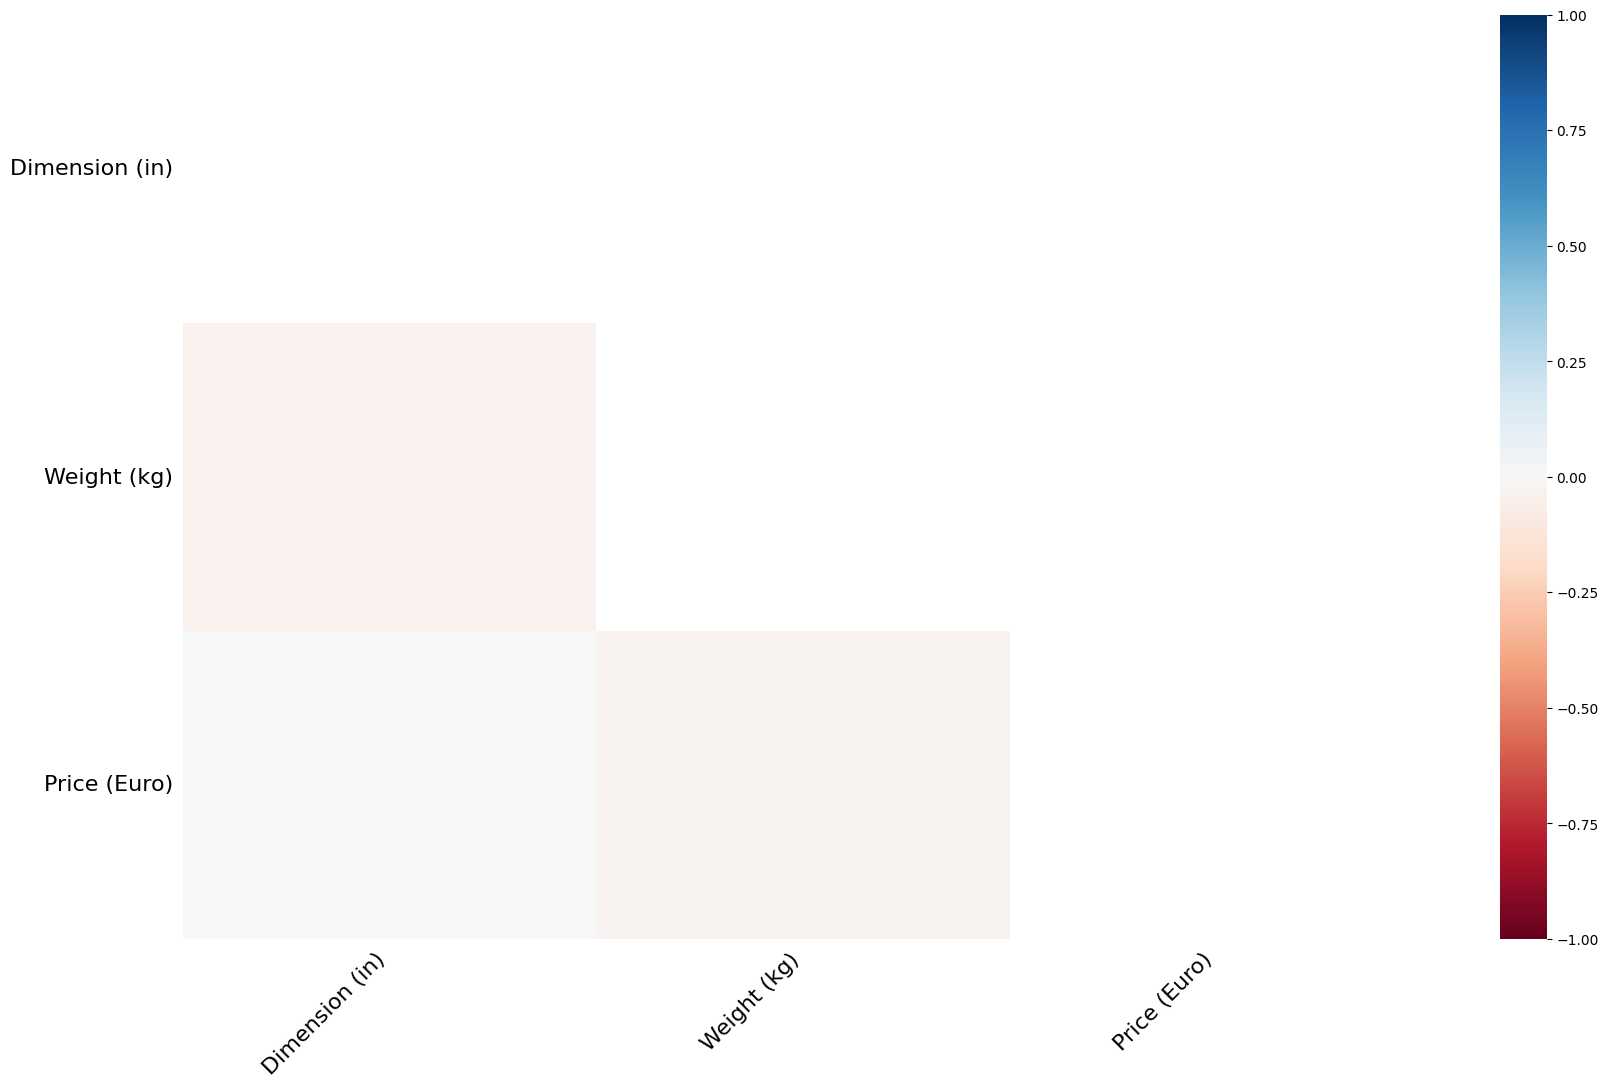

In [302]:
msno.heatmap(df)

<Axes: >

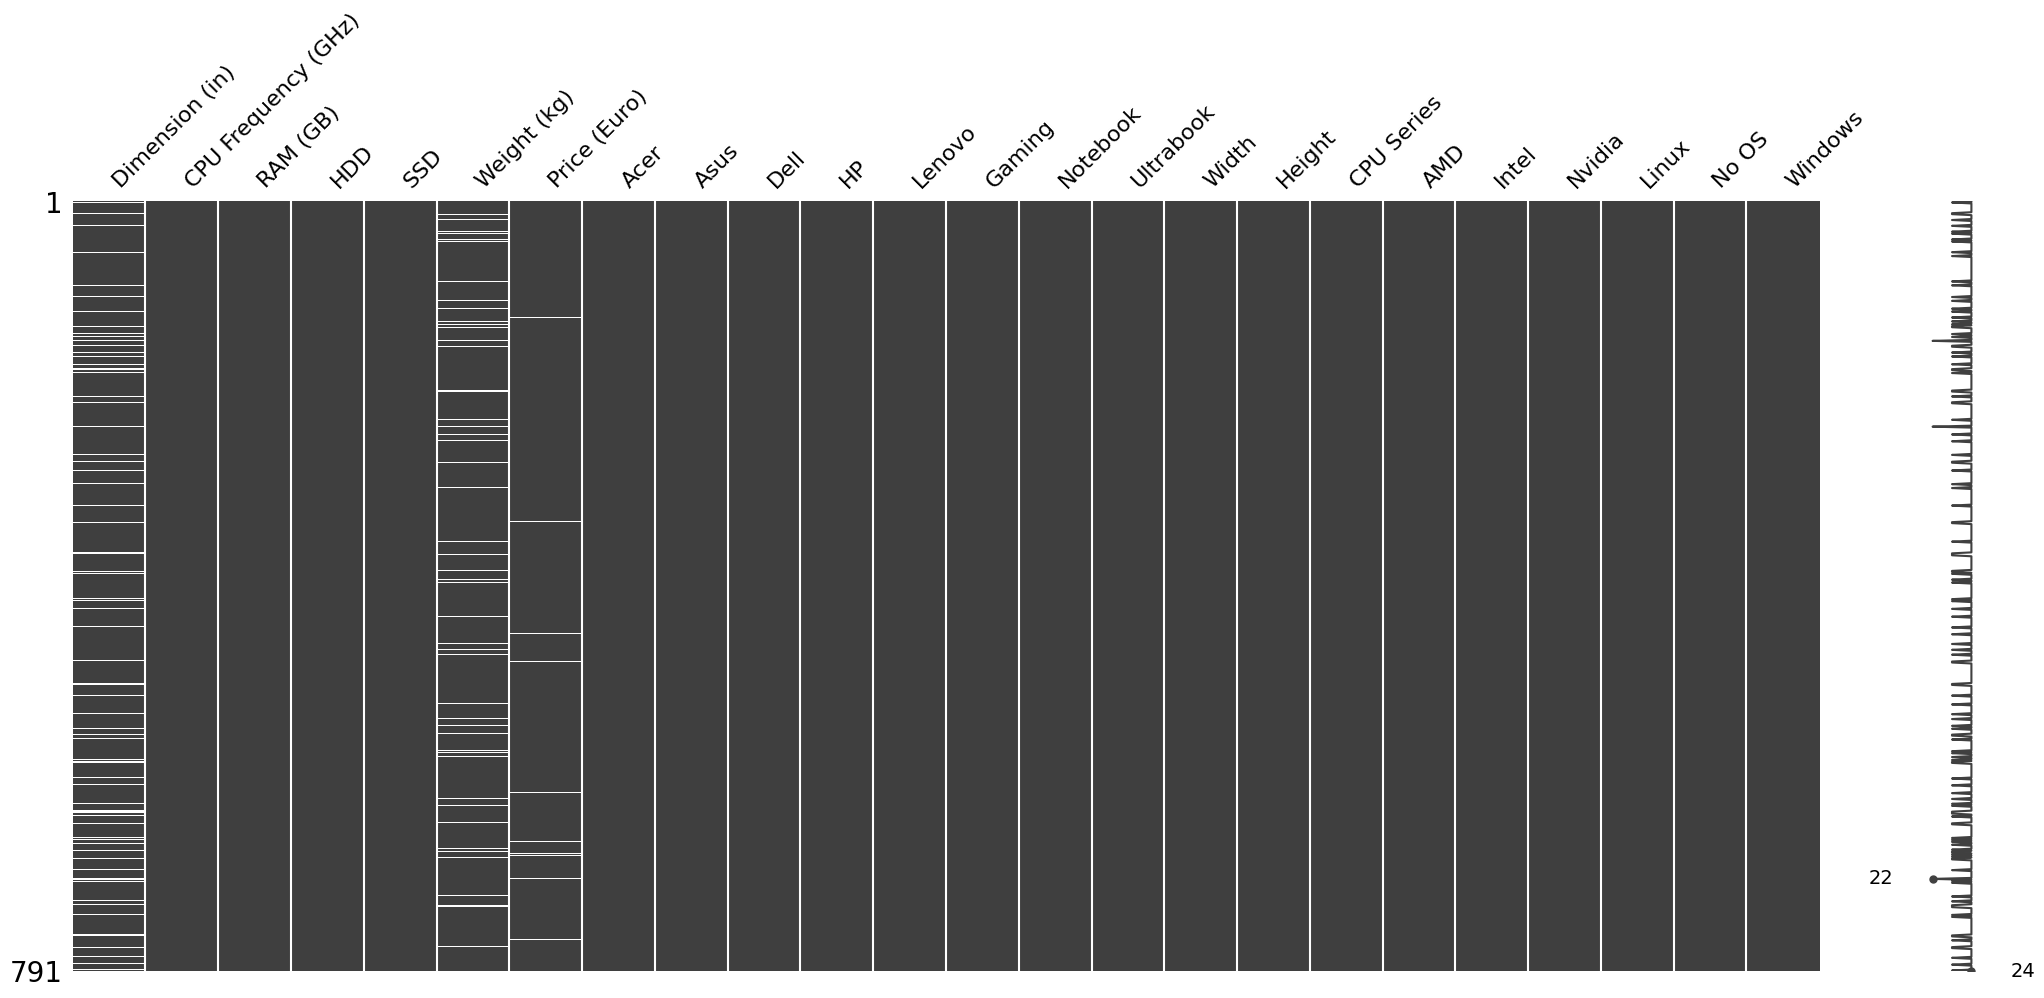

In [303]:
msno.matrix(df)

<Axes: >

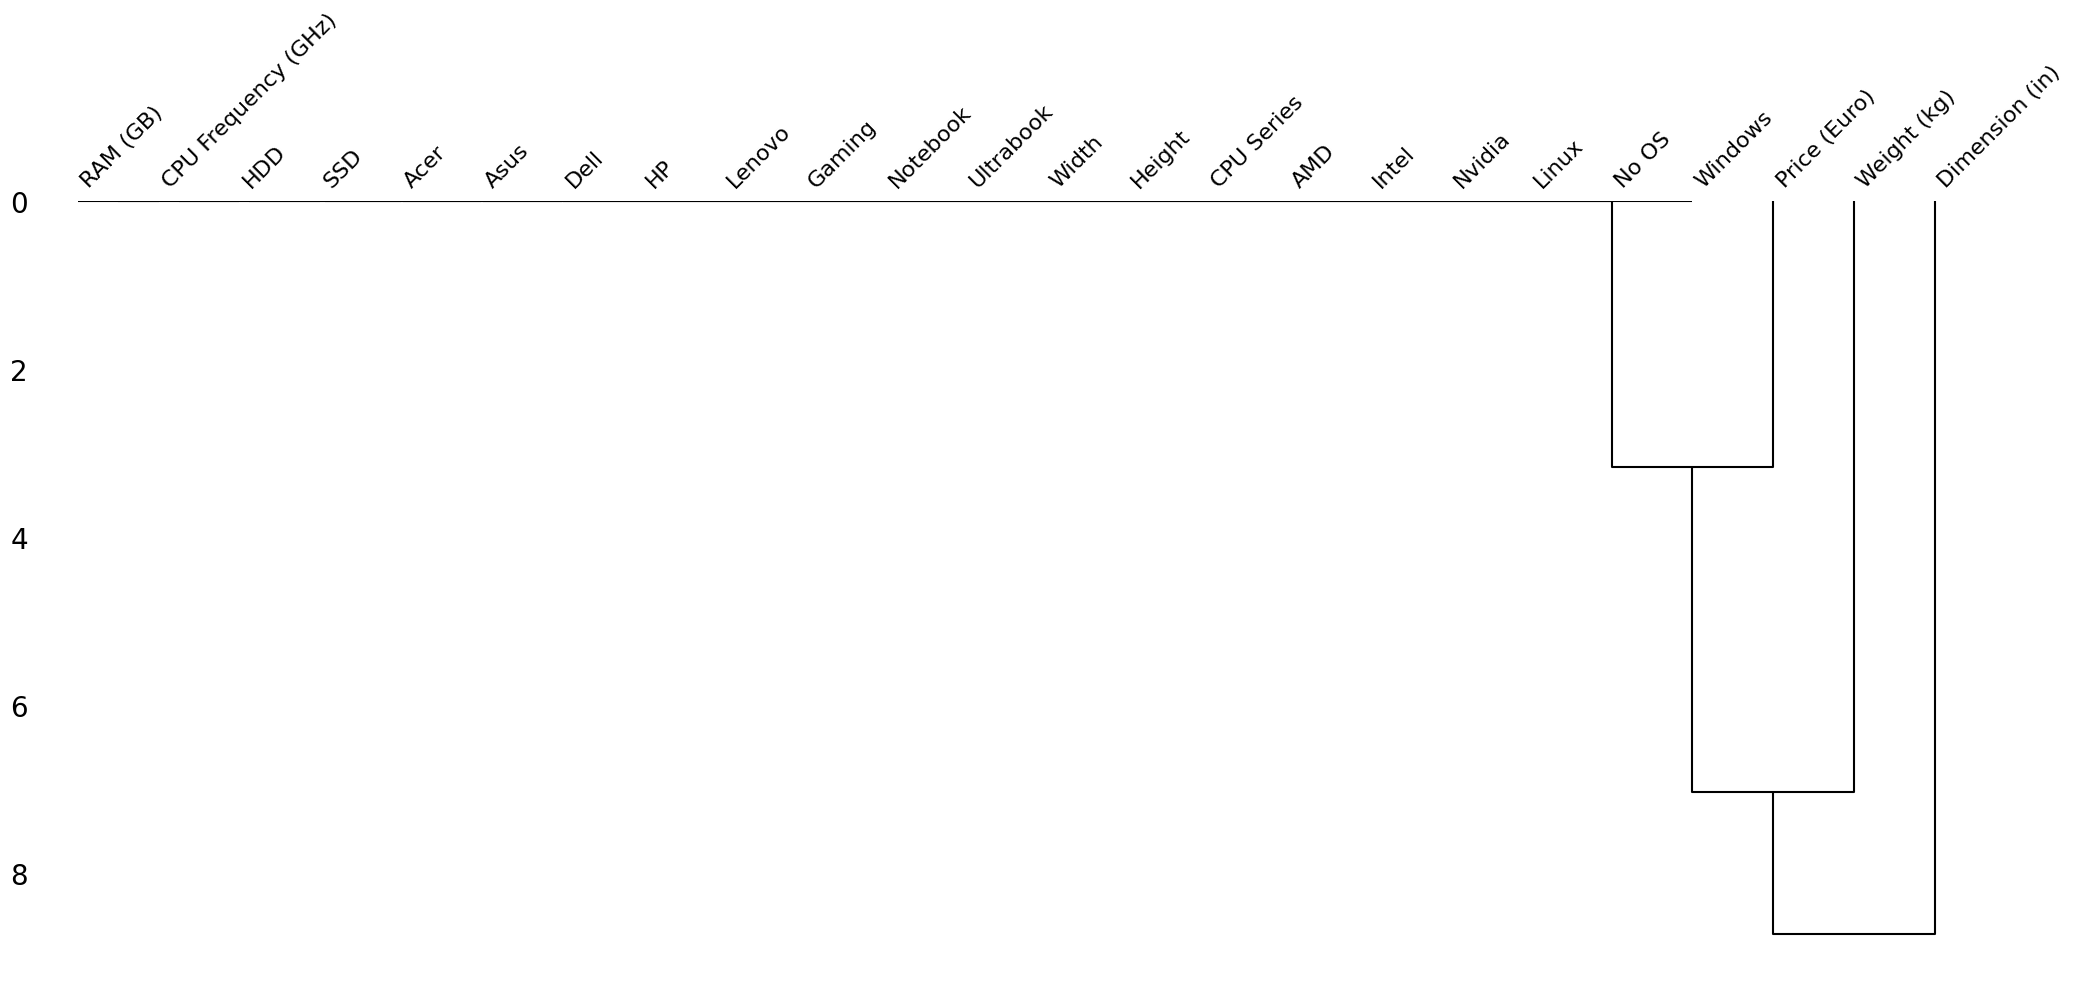

In [304]:
msno.dendrogram(df)

<Axes: ylabel='Frequency'>

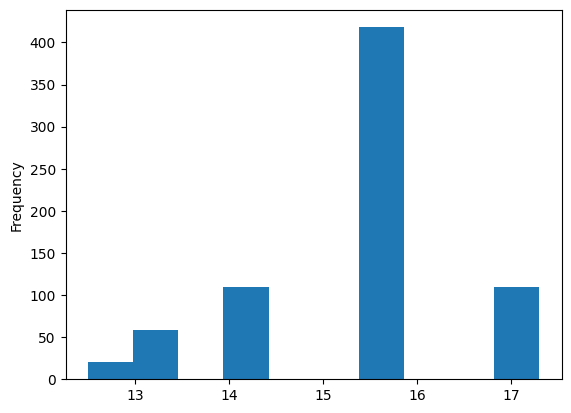

In [305]:
df["Dimension (in)"].plot.hist()

<Axes: ylabel='Frequency'>

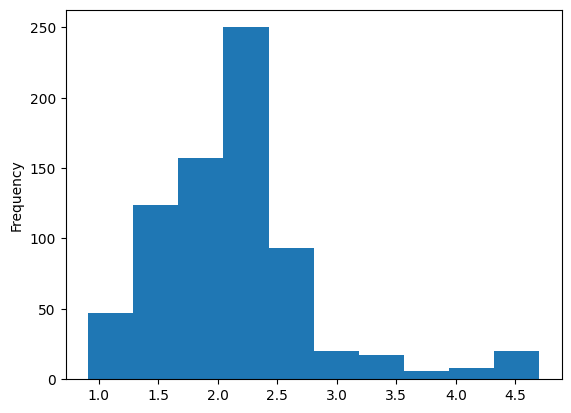

In [306]:
df["Weight (kg)"].plot.hist()

<Axes: >

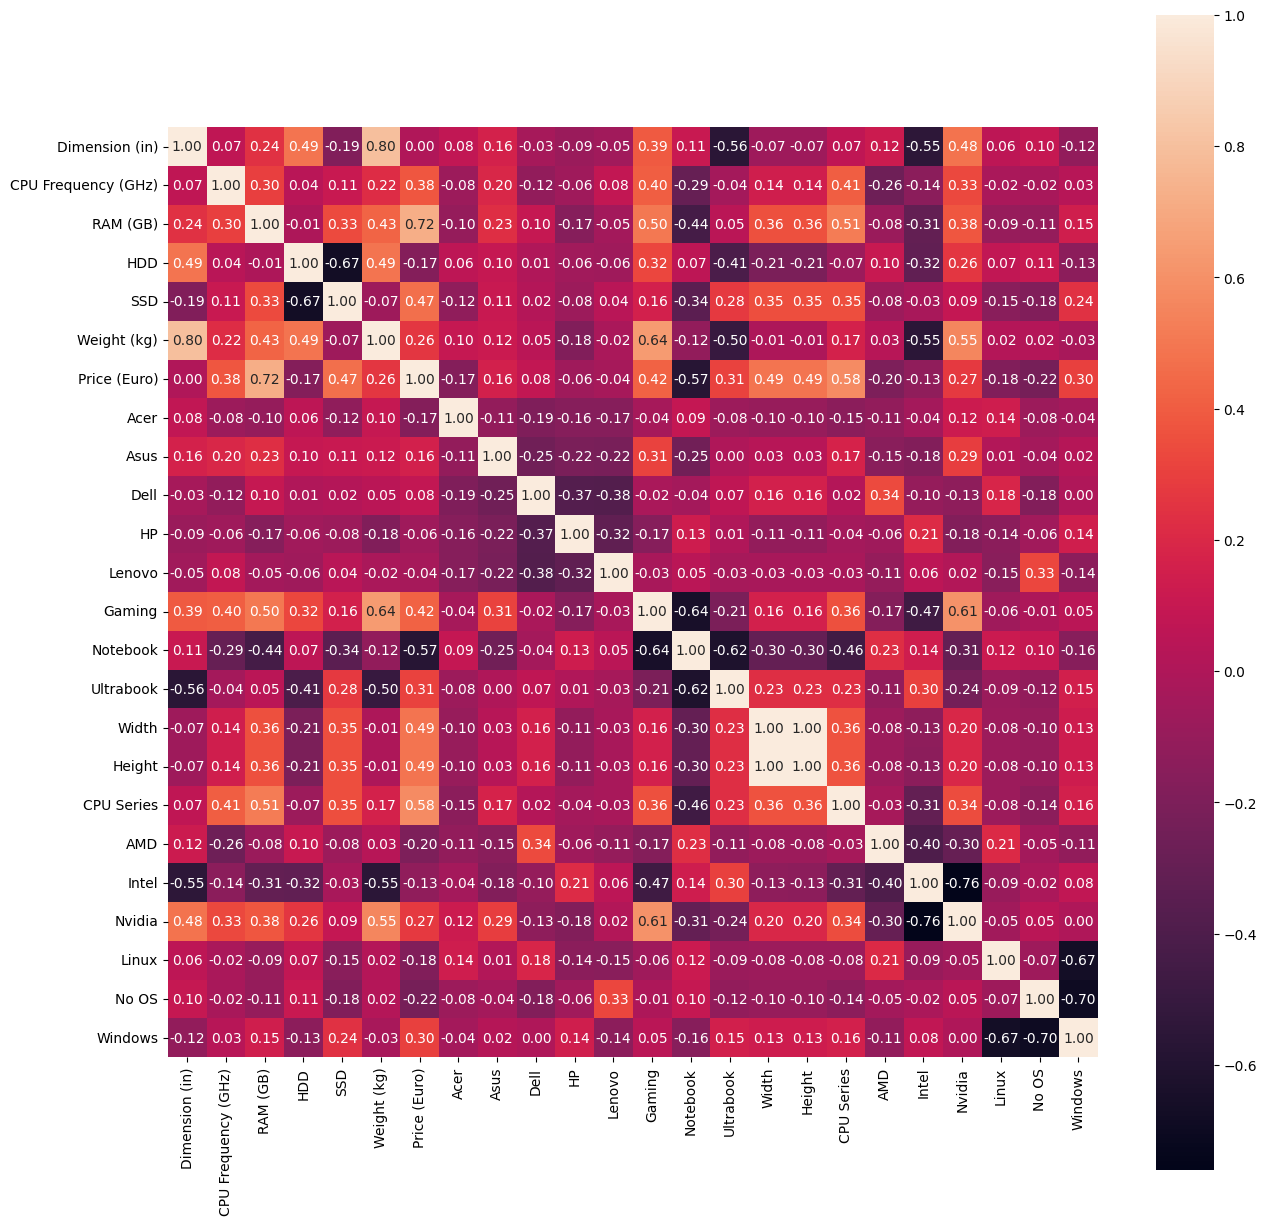

In [307]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", square=True)

<Axes: >

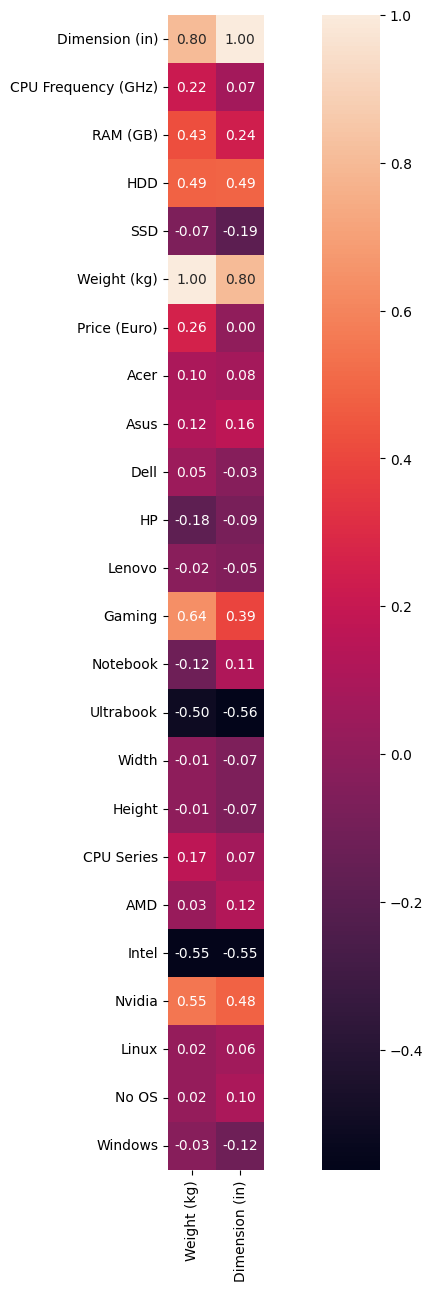

In [308]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(numeric_only=True)[["Weight (kg)", "Dimension (in)"]], annot=True, fmt=".2f", square=True)

In [309]:
cols = ["Weight (kg)", "Dimension (in)", "Gaming", "Ultrabook", "Intel", "Nvidia"]

In [310]:
iterative_imputer = IterativeImputer()

In [311]:
df[cols] = iterative_imputer.fit_transform(df[cols])

In [312]:
df.isnull().sum()

Dimension (in)          0
CPU Frequency (GHz)     0
RAM (GB)                0
HDD                     0
SSD                     0
Weight (kg)             0
Price (Euro)           10
Acer                    0
Asus                    0
Dell                    0
HP                      0
Lenovo                  0
Gaming                  0
Notebook                0
Ultrabook               0
Width                   0
Height                  0
CPU Series              0
AMD                     0
Intel                   0
Nvidia                  0
Linux                   0
No OS                   0
Windows                 0
dtype: int64

In [313]:
df.dropna(subset=["Price (Euro)"], axis=0, inplace=True)

In [314]:
df.isnull().sum()

Dimension (in)         0
CPU Frequency (GHz)    0
RAM (GB)               0
HDD                    0
SSD                    0
Weight (kg)            0
Price (Euro)           0
Acer                   0
Asus                   0
Dell                   0
HP                     0
Lenovo                 0
Gaming                 0
Notebook               0
Ultrabook              0
Width                  0
Height                 0
CPU Series             0
AMD                    0
Intel                  0
Nvidia                 0
Linux                  0
No OS                  0
Windows                0
dtype: int64

In [315]:
X, y = df.drop(columns=["Price (Euro)"]), df["Price (Euro)"]

In [316]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2)

In [317]:
regressor = KNeighborsRegressor(n_neighbors=3).fit(train_X, train_y)

pred_y = regressor.predict(test_X)

print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 228.67174097664542
MAPE: 0.20000747884317144
MSE: 113674.0351317056
RMSE: 337.1558024589012
R2 Score: 0.7234928191855022


In [318]:
regressor = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=3,
    min_samples_leaf=2,
).fit(train_X, train_y)

pred_y = regressor.predict(test_X)

print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 261.16514532493335
MAPE: 0.2375183062967983
MSE: 165909.47521440126
RMSE: 407.319868425788
R2 Score: 0.5964323672614


In [319]:
regressor = RandomForestRegressor(
    n_estimators=100,
).fit(train_X, train_y)

pred_y = regressor.predict(test_X)

print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 213.9602823657871
MAPE: 0.1741414051519733
MSE: 110345.15074411102
RMSE: 332.18240583166204
R2 Score: 0.7315901866819996


In [320]:
regressor = XGBRegressor(
    n_estimators=100,
).fit(train_X, train_y)

pred_y = regressor.predict(test_X)

print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 206.28282004969896
MAPE: 0.1714280294213848
MSE: 105158.14585829296
RMSE: 324.2809674623119
R2 Score: 0.7442073520371911


In [321]:
param_grid = {
    "n_neighbors": range(2, 10 + 1),
}

In [322]:
regressor = KNeighborsRegressor()

In [323]:
grid_search = GridSearchCV(
    regressor,
    param_grid,
    scoring="r2",
    cv=5,
)

In [324]:
grid_search.fit(train_X, train_y)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': range(2, 11)}, scoring='r2')

In [325]:
grid_search.best_params_

{'n_neighbors': 5}

In [326]:
pred_y = grid_search.predict(test_X)

In [327]:
print(f"MAE: {mean_absolute_error(test_y, pred_y)}")
print(f"MAPE: {mean_absolute_percentage_error(test_y, pred_y)}")
print(f"MSE: {mean_squared_error(test_y, pred_y)}")
print(f"RMSE: {root_mean_squared_error(test_y, pred_y)}")
print(f"R2 Score: {r2_score(test_y, pred_y)}")

MAE: 234.7980382165605
MAPE: 0.209943915416557
MSE: 125611.65827368152
RMSE: 354.4173504128734
R2 Score: 0.6944550664850793
